# Bloque 3 · Expresión facial: del vídeo a `face.csv`

Este notebook recorre, paso a paso y con imágenes, cómo se obtiene la expresión facial de la presidenta a partir del vídeo de una rueda de prensa. Es la explicación del proceso; el código de producción está en `src/vision/` y la comparación de modelos irá en los notebooks de `benchmarks/`.

**Idea:** no usamos un modelo de vídeo. El vídeo se convierte en fotogramas (uno por segundo) y cada fotograma se analiza como una imagen:

```
vídeo → fotogramas (1 fps) → detectar caras (YuNet) → ¿primer plano?
      → ¿es la presidenta? (SFace) → recortar la cara → expresión (HSEmotion) → face.csv
```

| Paso | Modelo | Qué hace | Dónde |
|---|---|---|---|
| Fotogramas | — (OpenCV) | Un fotograma por segundo | `src/vision/frames.py` |
| Detección | YuNet (OpenCV, ONNX, ~230 KB) | Encuentra las caras y su tamaño | `src/vision/detect.py` |
| Identificación | SFace (OpenCV, ONNX, ~37 MB) | ¿Es la presidenta o un periodista? | `src/vision/detect.py` |
| Expresión | HSEmotion `enet_b0_8_va_mtl` (ONNX, ~16 MB) | 8 emociones + valence y arousal | `src/vision/models/hsemotion.py` |

Todo el proceso se ejecuta desde este notebook en Python, sin comandos de terminal: cada paso llama a las mismas funciones de `src/` que usa el pipeline.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))  # raíz del repo (el notebook está en docs/)

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.config import RAW_DIR, event_dir, load_config
from src.vision.detect import FaceDetector
from src.vision.face import MIN_CLOSEUP_AREA, classify_shot, load_identifier
from src.vision.models import get_face_backend
from src.vision.schema import EMOTIONS

EVENT = load_config()["reference_event"]
VIDEO = RAW_DIR / f"{EVENT}.mp4"


def frame_at(second: float) -> np.ndarray:
    # Fotograma RGB en un segundo concreto (para ilustrar; el proceso real lee el vídeo en orden)
    cap = cv2.VideoCapture(str(VIDEO))
    cap.set(cv2.CAP_PROP_POS_MSEC, second * 1000)
    ok, frame = cap.read()
    cap.release()
    return cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)


def mmss(s: float) -> str:
    return f"{int(s) // 60:02d}:{int(s) % 60:02d}"

## 1. El vídeo

Rueda de prensa del 10 de septiembre de 2026 (Berlín), del canal oficial del BCE. La función `download` de `scripts/download_videos.py` la descarga a 720p en `data/raw/` (si ya está descargada, no hace nada).

In [2]:
sys.path.insert(0, str(Path.cwd().parent / "scripts"))
from download_videos import download, load_urls

VIDEO = download(EVENT, load_urls()[EVENT])

[2026-09-10] ya descargado: C:\Users\bogar\Master\Multimodales\hawk-and-dove_BCE\data\raw\2026-09-10.mp4


In [3]:
cap = cv2.VideoCapture(str(VIDEO))
fps = cap.get(cv2.CAP_PROP_FPS)
n = cap.get(cv2.CAP_PROP_FRAME_COUNT)
w, h = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)), int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
cap.release()
print(f"{VIDEO.name}: {w}x{h}, {fps:.0f} fotogramas/s, {n / fps / 60:.1f} minutos")
print(f"A 1 fotograma por segundo → {int(n / fps)} imágenes que analizar (de {int(n)} fotogramas)")

2026-09-10.mp4: 1280x720, 30 fotogramas/s, 50.9 minutos
A 1 fotograma por segundo → 3051 imágenes que analizar (de 91552 fotogramas)


## 2. De vídeo a fotogramas

Tomamos un fotograma por segundo: la expresión no cambia en menos tiempo y así el proceso es 30 veces más ligero. Estos son cuatro momentos típicos de la rueda: la realización alterna entre la presidenta, el plano general del panel y los periodistas que preguntan.

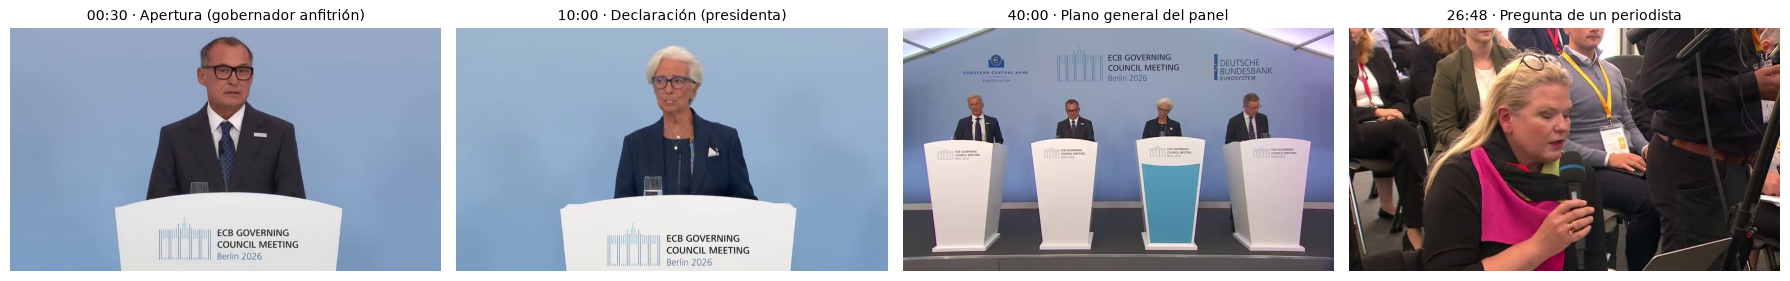

In [4]:
MOMENTS = {30: "Apertura (gobernador anfitrión)", 600: "Declaración (presidenta)",
           2400: "Plano general del panel", 1608: "Pregunta de un periodista"}
frames = {t: frame_at(t) for t in MOMENTS}

fig, axes = plt.subplots(1, 4, figsize=(18, 3.2))
for ax, (t, title) in zip(axes, MOMENTS.items()):
    ax.imshow(frames[t]); ax.set_title(f"{mmss(t)} · {title}", fontsize=10); ax.axis("off")
plt.tight_layout()

## 3. Detectar caras y decidir si es un primer plano

YuNet devuelve una caja por cada cara. Con el tamaño de la caja decidimos el tipo de plano: si la cara principal ocupa al menos un 0,8 % del fotograma es un **primer plano** (`closeup`) y se analiza; si no, es un **plano general** (`wide`) y la cara es demasiado pequeña para leer la expresión.

El umbral se midió en este vídeo: la presidenta en el atril ocupa ~1,7-2,8 % de la imagen y cada cara del plano general, ~0,15-0,2 %.

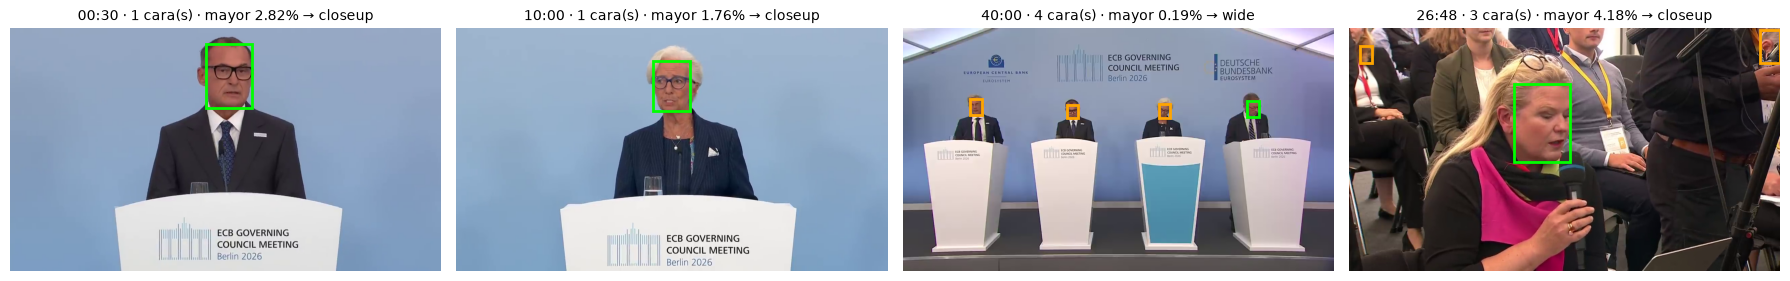

In [5]:
detector = FaceDetector()

fig, axes = plt.subplots(1, 4, figsize=(18, 3.2))
for ax, (t, img) in zip(axes, frames.items()):
    faces = detector.detect(img)
    shot = classify_shot(faces[0] if faces else None, img.shape)
    ax.imshow(img); ax.axis("off")
    for i, f in enumerate(faces):
        x, y, bw, bh = f.box
        ax.add_patch(plt.Rectangle((x, y), bw, bh, fill=False, lw=2, color="lime" if i == 0 else "orange"))
    area = faces[0].area / (img.shape[0] * img.shape[1]) if faces else 0
    ax.set_title(f"{mmss(t)} · {len(faces)} cara(s) · mayor {area:.2%} → {shot}", fontsize=10)
plt.tight_layout()

## 4. ¿Quién es? Reconocer a la presidenta

En los primeros planos también salen el gobernador anfitrión y los periodistas, así que hay que saber de quién es la cara. SFace convierte cada cara en un vector de 128 números; dos fotos de la misma persona dan vectores parecidos (similitud coseno alta). Comparamos con tres fotos de referencia de la presidenta (`data/references/presidenta/`): si la similitud supera 0,363 (el umbral recomendado por OpenCV) es ella; si no, `otro`.

00:30 Apertura (gobernador anfitrión)     similitud  0.07 → otro
10:00 Declaración (presidenta)            similitud  0.96 → presidenta
26:48 Pregunta de un periodista           similitud  0.25 → otro


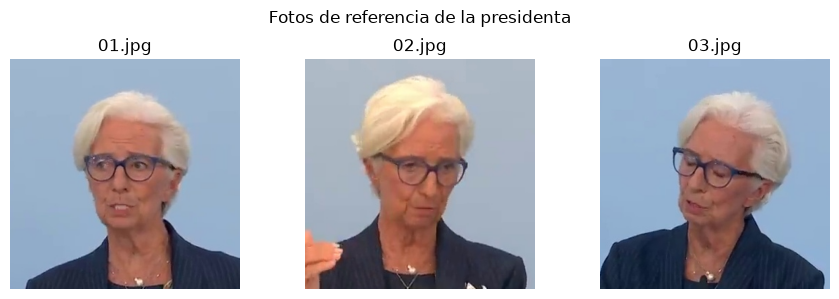

In [6]:
refs = sorted((Path.cwd().parent / "data/references/presidenta").glob("*.jpg"))
fig, axes = plt.subplots(1, len(refs), figsize=(3 * len(refs), 3))
for ax, p in zip(axes, refs):
    ax.imshow(cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB)); ax.set_title(p.name); ax.axis("off")
fig.suptitle("Fotos de referencia de la presidenta")
plt.tight_layout()

identifier = load_identifier(detector)
for t in (30, 600, 1608):
    face = detector.detect(frames[t])[0]
    person, sim = identifier.identify(frames[t], face)
    print(f"{mmss(t)} {MOMENTS[t]:<35} similitud {sim:5.2f} → {person or 'otro'}")

## 5. Recortar la cara y leer la expresión

Al modelo de expresión no le pasamos el fotograma entero (la cara sería un 2 % de la imagen), sino un recorte cuadrado de la cara con un pequeño margen. HSEmotion devuelve:

- **8 emociones** con su probabilidad (suman 1): neutral, alegría, tristeza, sorpresa, miedo, enfado, asco y desprecio.
- **Valence** en [−1, 1]: negativa = expresión desagradable o tensa; positiva = agradable.
- **Arousal** en [−1, 1]: negativo = calmada; positivo = activada.

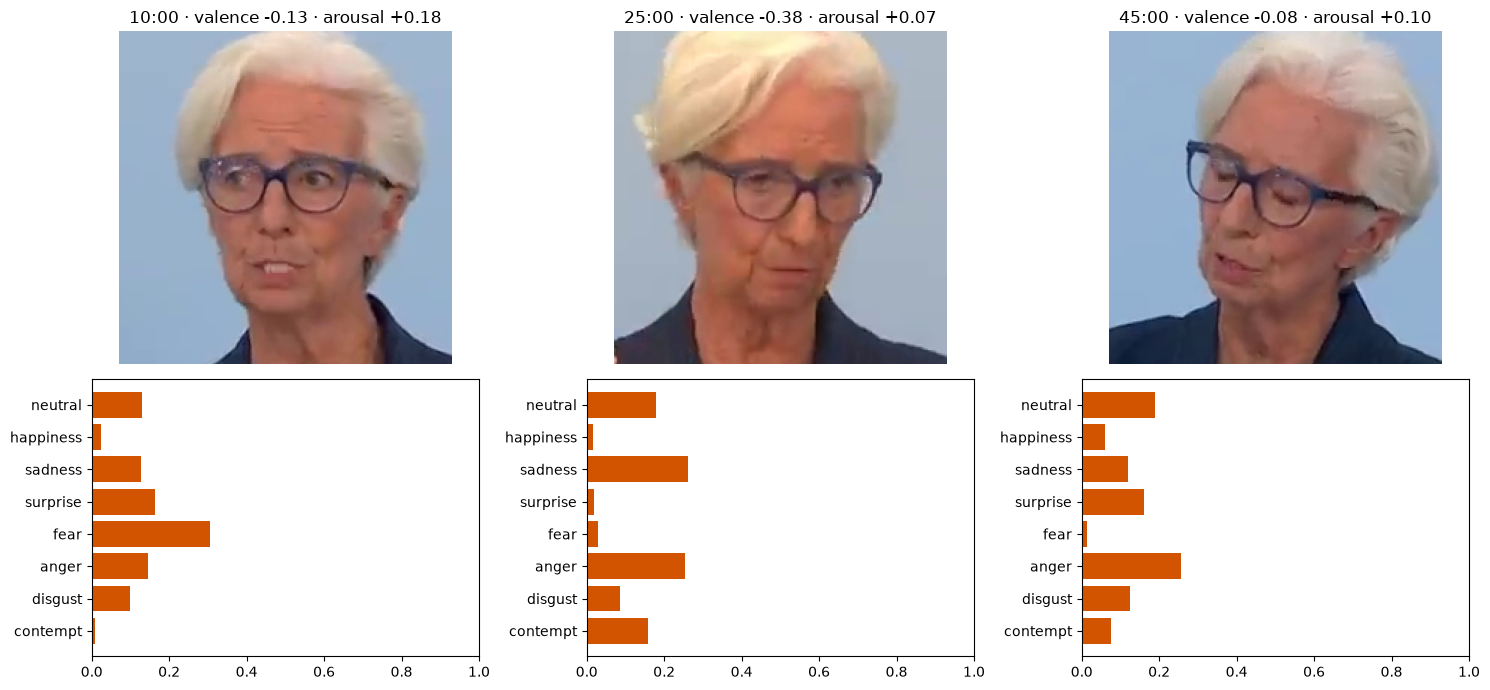

In [7]:
backend = get_face_backend("hsemotion")
SAMPLES = [600, 1500, 2700]

fig, axes = plt.subplots(2, len(SAMPLES), figsize=(15, 7), gridspec_kw={"height_ratios": [1.2, 1]})
for col, t in enumerate(SAMPLES):
    img = frame_at(t)
    face = detector.detect(img)[0]
    crop = detector.crop(img, face)
    r = backend.analyze(crop)
    axes[0, col].imshow(crop); axes[0, col].axis("off")
    axes[0, col].set_title(f"{mmss(t)} · valence {r['valence']:+.2f} · arousal {r['arousal']:+.2f}")
    axes[1, col].barh(EMOTIONS, [r["emotions"][e] for e in EMOTIONS], color="#d35400")
    axes[1, col].set_xlim(0, 1); axes[1, col].invert_yaxis()
plt.tight_layout()

Las probabilidades se reparten entre varias emociones y cambian de un segundo a otro: al hablar, la boca adopta formas que el modelo confunde con sorpresa o miedo. Por eso no usamos la emoción ganadora de cada segundo, sino las series suavizadas en el tiempo y su comparación con la media de la propia presidenta.

## 6. El proceso completo

Lo anterior, repetido para cada segundo del vídeo, lo hacen dos funciones de `src/vision/face.py`: `analyze_video` recorre el vídeo y devuelve la tabla, y `write_face_csv` la guarda en `data/events/<fecha>/face.csv`, una fila por segundo.

En un portátil sin GPU tarda unos 3 minutos para la rueda completa (~3.050 segundos de vídeo, ~13 ms por cara). Si `face.csv` ya existe se reutiliza; pon `RECALCULAR = True` para volver a generarlo.

In [8]:
import time
from src.vision.face import analyze_video, write_face_csv

RECALCULAR = False
out = event_dir(EVENT) / "face.csv"
if RECALCULAR or not out.exists():
    t0 = time.perf_counter()
    write_face_csv(analyze_video(VIDEO, backend), event_dir(EVENT))
    print(f"face.csv generado en {time.perf_counter() - t0:.0f} s")
else:
    print(f"Usando el face.csv ya generado: {out}")

Usando el face.csv ya generado: C:\Users\bogar\Master\Multimodales\hawk-and-dove_BCE\data\events\2026-09-10\face.csv


In [9]:
face = pd.read_csv(event_dir(EVENT) / "face.csv")
print(f"{len(face)} segundos")
print(face["shot_type"].value_counts().rename("tipo de plano").to_string(), "\n")
print(face["person"].value_counts().rename("persona en primer plano").to_string())
face[face["person"] == "presidenta"].head()

3052 segundos
shot_type
closeup    2976
wide         76 

person
presidenta    2439
otro           537


,start,end,face_detected,person,shot_type,valence,arousal,p_neutral,p_happiness,p_sadness,p_surprise,p_fear,p_anger,p_disgust,p_contempt,au04_brow_lowerer,au12_lip_corner_puller,au24_lip_pressor
66,66.0,67.0,True,presidenta,closeup,-0.021,0.008,0.607,0.059,0.058,0.065,0.024,0.121,0.017,0.049,NaN,NaN,NaN
67,67.0,68.0,True,presidenta,closeup,0.330,-0.133,0.166,0.341,0.037,0.014,0.002,0.018,0.142,0.279,NaN,NaN,NaN
68,68.0,69.0,True,presidenta,closeup,0.480,-0.024,0.084,0.575,0.008,0.041,0.005,0.018,0.052,0.217,NaN,NaN,NaN
83,83.0,84.0,True,presidenta,closeup,-0.268,0.325,0.219,0.028,0.094,0.140,0.007,0.426,0.018,0.068,NaN,NaN,NaN
84,84.0,85.0,True,presidenta,closeup,0.389,0.106,0.082,0.485,0.021,0.055,0.005,0.054,0.046,0.252,NaN,NaN,NaN


## 7. Qué dicen los datos

Valence de la presidenta a lo largo de la rueda (media móvil de 30 s). Las marcas grises son los segundos en que la realización enfoca a otra persona, casi siempre un periodista preguntando: separan la **declaración inicial** (lee el texto) de la **ronda de preguntas** (responde sin texto).

             valence  arousal
declaración    -0.19     0.16
preguntas      -0.07     0.08


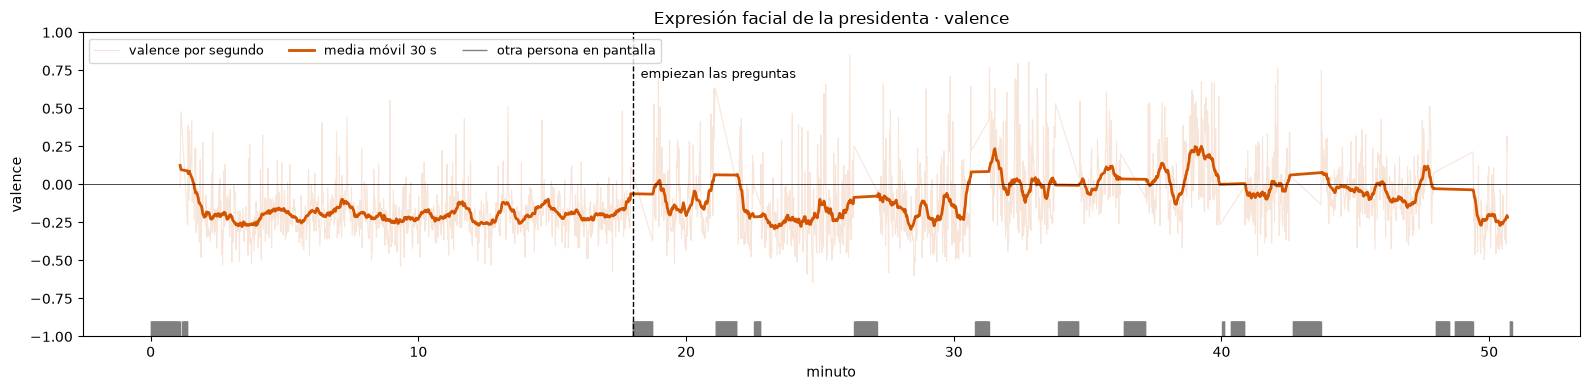

In [10]:
pres = face[face["person"] == "presidenta"].set_index("start")
smooth = pres["valence"].rolling(30, min_periods=10, center=True).mean()
others = face[face["person"] == "otro"]["start"]
first_question = others[others > 120].min()  # primer periodista tras la apertura

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(pres.index / 60, pres["valence"], color="#d35400", alpha=0.15, lw=0.8, label="valence por segundo")
ax.plot(smooth.index / 60, smooth, color="#d35400", lw=2, label="media móvil 30 s")
ax.vlines(others / 60, -1, -0.9, color="grey", lw=1, label="otra persona en pantalla")
ax.axvline(first_question / 60, color="black", ls="--", lw=1)
ax.text(first_question / 60 + 0.3, 0.7, "empiezan las preguntas", fontsize=9)
ax.axhline(0, color="black", lw=0.5)
ax.set(xlabel="minuto", ylabel="valence", ylim=(-1, 1), title="Expresión facial de la presidenta · valence")
ax.legend(loc="upper left", ncol=3, fontsize=9)
plt.tight_layout()

section = np.where(pres.index < first_question, "declaración", "preguntas")
print(pres.groupby(section)[["valence", "arousal"]].mean().round(2).to_string())

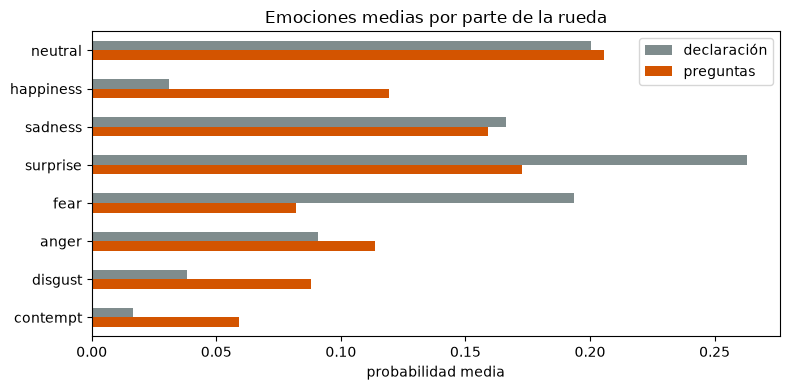

In [11]:
probs = pres[[f"p_{e}" for e in EMOTIONS]].groupby(section).mean().T
probs.index = EMOTIONS
ax = probs.plot.barh(figsize=(8, 4), color=["#7f8c8d", "#d35400"])
ax.invert_yaxis(); ax.set(xlabel="probabilidad media", title="Emociones medias por parte de la rueda")
plt.tight_layout()

## 8. Limitaciones y siguientes pasos

- **Caras contenidas:** una banquera central apenas gesticula y las diferencias son pequeñas. Lo más útil es la desviación respecto a su propia media, que se podrá calcular con las 6-10 ruedas de la demo.
- **Hablar mueve la boca** y el modelo lo confunde a veces con sorpresa o miedo; se mitiga suavizando en el tiempo.
- **Gafas:** dificultan las señales de los ojos.
- **Leer frente a improvisar:** en la declaración mira el texto y la cara sale más «negativa»; parte de esa diferencia puede deberse a mirar hacia abajo y no a la emoción. Conviene tenerlo en cuenta al interpretar.
- **Siguientes pasos:** probar los otros dos candidatos (py-feat, que añade los Action Units, y SigLIP zero-shot) y compararlos en el notebook de benchmark con ~100 fotogramas etiquetados a mano.